# Визуализация данных с Matplotlib

In [ ]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (10, 6)  # Размер графиков по умолчанию
plt.rcParams['font.size'] = 10  # Размер шрифта

#%matplotlib inline  # Отображение графиков прямо в ноутбуке  # Отображение графиков прямо в ноутбуке

UsageError: unrecognized arguments: # Отображение графиков прямо в ноутбуке


### Загрузка датасета

Мы будем использовать датасет с температурами крупных городов мира.  
Источник: https://www.kaggle.com/datasets/sudalairajkumar/daily-temperature-of-major-cities

In [ ]:
# Загрузка датасета
df = pd.read_csv('city_temperature.csv', low_memory=False)


In [ ]:
# Подготовим данные для работы
# Температуры в датасете в Фаренгейтах, переведем в Цельсии
# Формула: C = (F - 32) * 5/9
df['TempC'] = (df['AvgTemperature'] - 32) * 5 / 9

# Создадим колонку с датой для удобства
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']], errors='coerce')


---
## 1. Введение в Matplotlib

### Что такое Matplotlib?

**Matplotlib** — это основная библиотека для создания статических, анимированных и интерактивных визуализаций в Python.

### Почему визуализация важна?

- **Понимание данных**: Один график стоит тысячи чисел
- **Поиск паттернов**: Легко заметить тренды, циклы, аномалии
- **Коммуникация**: Донести инсайты до аудитории
- **Проверка гипотез**: Визуально оценить взаимосвязи

---

### Архитектура Matplotlib

Matplotlib имеет **иерархическую структуру**:

```
Figure (фигура, окно)
    └── Axes (система координат, график)
            └── Axis (ось X или Y)
            └── Line, Bar, Scatter... (элементы графика)
            └── Title, Labels, Legend... (подписи)
```

**Основные объекты:**

1. **Figure** (`fig`) - это контейнер верхнего уровня, "холст" для рисования
   - Можно сохранять в файл
   - Может содержать несколько Axes (подграфиков)
   
2. **Axes** (`ax`) - это область для построения графика
   - Содержит оси X и Y
   - На нём рисуются данные (линии, точки, столбцы)
   - Имеет заголовок, подписи осей, легенду

---

### Два стиля работы с Matplotlib

#### 1. **pyplot стиль** (простой, для быстрых графиков):

```python
plt.plot([1, 2, 3], [1, 4, 9])
plt.title('Мой график')
plt.show()
```

**Плюсы:** быстро, просто, похоже на MATLAB  
**Минусы:** сложно управлять несколькими графиками

#### 2. **Object-Oriented стиль** (гибкий, для сложных визуализаций):

```python
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])
ax.set_title('Мой график')
plt.show()
```

**Плюсы:** полный контроль, легко работать с несколькими графиками  
**Минусы:** чуть больше кода

**Мы будем использовать оба подхода**, но чаще Object-Oriented как более гибкий.

### Демонстрация разницы между подходами

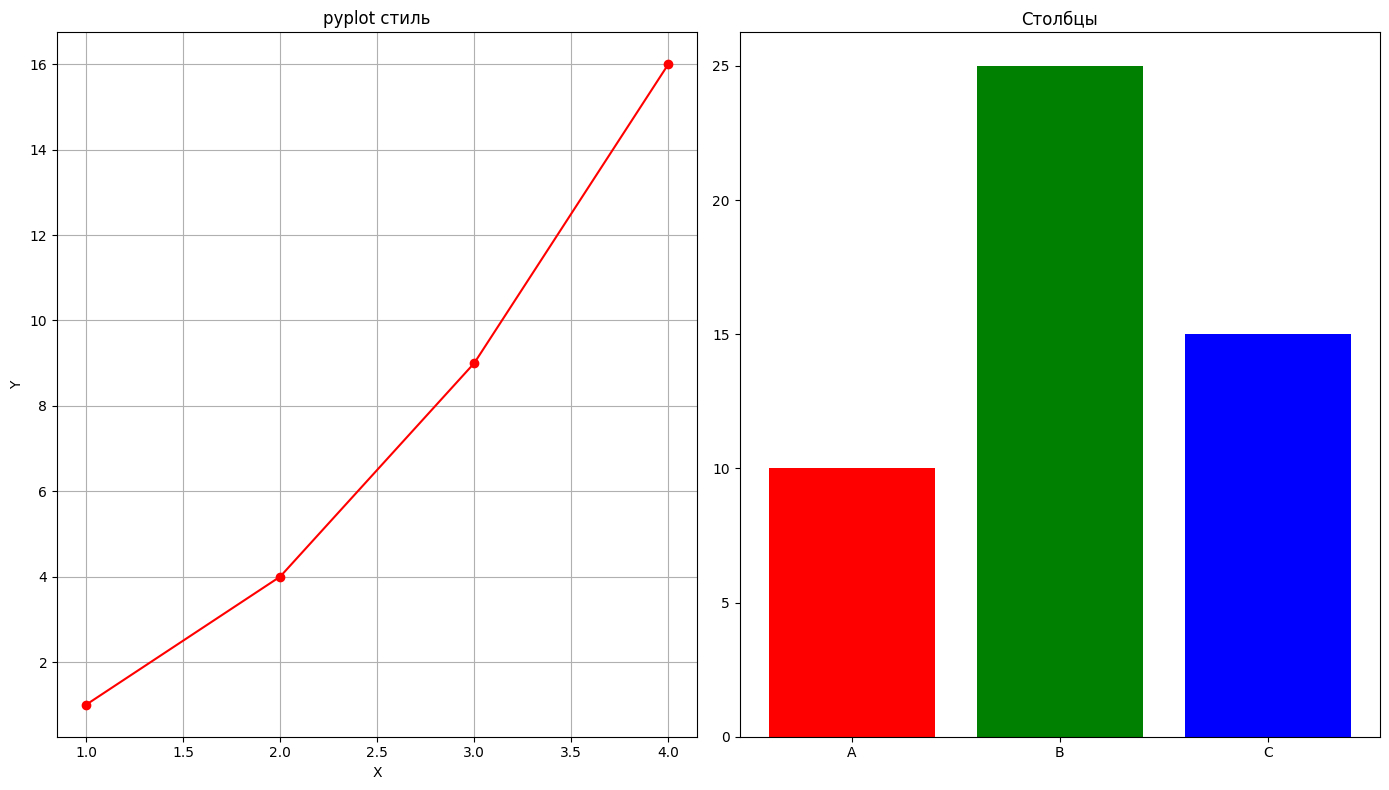

Pyplot стиль - быстро, но менее гибко для сложных композиций


In [ ]:
# PYPLOT СТИЛЬ
plt.figure(figsize=(14, 8))

# Первый график
plt.subplot(1, 2, 1)  # 1 строка, 2 колонки, первая позиция
plt.plot([1, 2, 3, 4], [1, 4, 9, 16], 'ro-')
plt.title('pyplot стиль')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True)

# Второй график
plt.subplot(1, 2, 2)  # 1 строка, 2 колонки, вторая позиция
plt.bar(['A', 'B', 'C'], [10, 25, 15],color=['red', 'green', 'blue'])
plt.title('Столбцы')

plt.tight_layout()
plt.show()

print("Pyplot стиль - быстро, но менее гибко для сложных композиций")

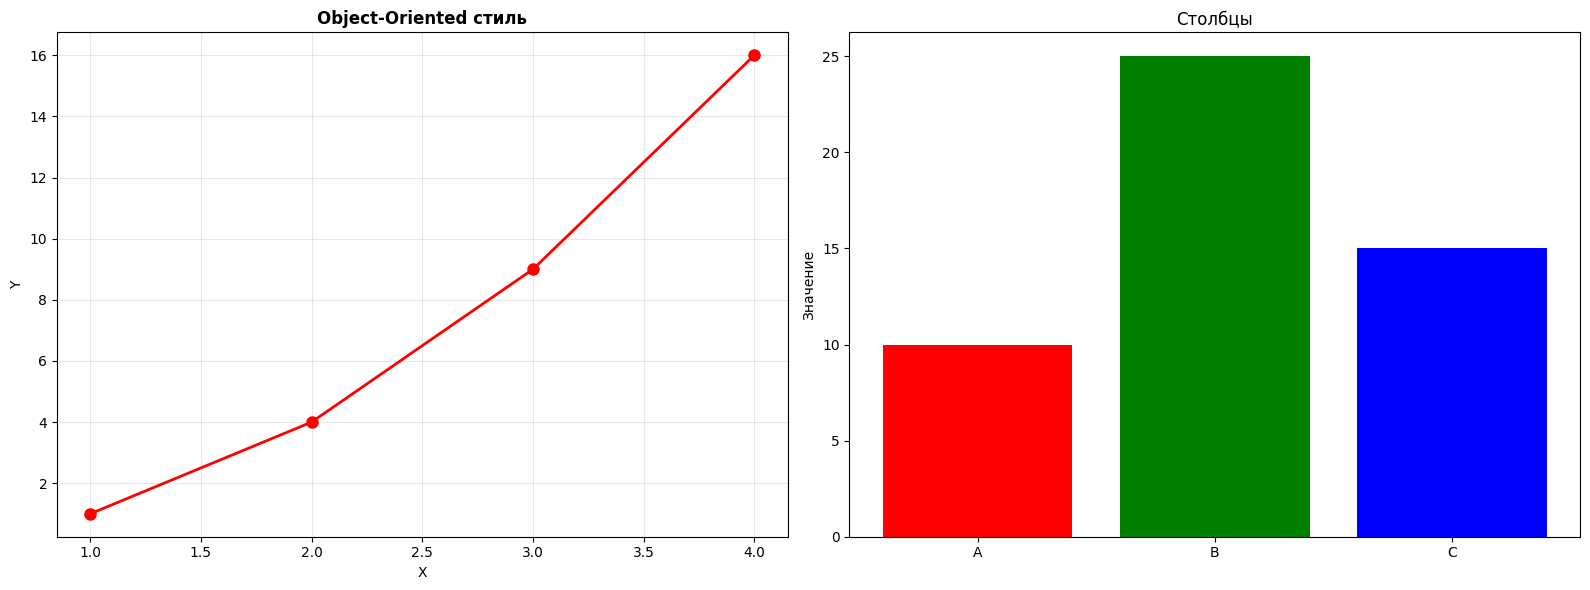

Object-Oriented стиль - больше контроля, легко модифицировать каждый график


In [ ]:
# OBJECT-ORIENTED СТИЛЬ (РЕКОМЕНДУЕТСЯ)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Создаем фигуру с 2 графиками

# Первый график (axes[0])
axes[0].plot([1, 2, 3, 4], [1, 4, 9, 16], 'ro-', linewidth=2, markersize=8)
axes[0].set_title('Object-Oriented стиль', fontsize=12, fontweight='bold')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(True, alpha=0.3)

# Второй график (axes[1])
axes[1].bar(['A', 'B', 'C'], [10, 25, 15], color=['red', 'green', 'blue'])
axes[1].set_title('Столбцы')
axes[1].set_ylabel('Значение')

plt.tight_layout()
plt.show()

print("Object-Oriented стиль - больше контроля, легко модифицировать каждый график")

**Вывод:** Object-Oriented стиль дает больше контроля и удобнее для сложных визуализаций!

---
## 2. Линейный график (Line Plot)

### Когда использовать?

**Идеально для:**
- Показа изменений во времени (временные ряды)
- Отображения трендов
- Сравнения нескольких показателей

**Примеры:** цены акций, температура, рост населения, продажи по месяцам

---

### Основные функции

```python
plt.plot(x, y)              # pyplot стиль
ax.plot(x, y)               # OO стиль
```

### Важные параметры:

| Параметр | Описание | Примеры |
|----------|----------|----------|
| `x, y` | Данные для осей X и Y | `x=[1,2,3], y=[2,4,6]` |
| `color` или `c` | Цвет линии | `'red'`, `'#FF5733'`, `'C0'` |
| `linestyle` или `ls` | Стиль линии | `'-'`, `'--'`, `'-.'`, `':'` |
| `linewidth` или `lw` | Толщина линии | `1`, `2`, `3` |
| `marker` | Маркеры на точках | `'o'`, `'s'`, `'^'`, `'*'`, `'.'` |
| `markersize` или `ms` | Размер маркеров | `5`, `10`, `15` |
| `label` | Название для легенды | `'Температура'` |
| `alpha` | Прозрачность (0-1) | `0.5`, `0.8`, `1.0` |

### Основные функции оформления:

```python
ax.set_title('Заголовок')       # Заголовок
ax.set_xlabel('Ось X')          # Подпись оси X
ax.set_ylabel('Ось Y')          # Подпись оси Y
ax.legend()                     # Легенда
ax.grid(True)                   # Сетка
ax.set_xlim([0, 10])           # Пределы оси X
ax.set_ylim([0, 100])          # Пределы оси Y
```

### Пример простого линейного графика

Text(0.5, 1.0, 'Температура')

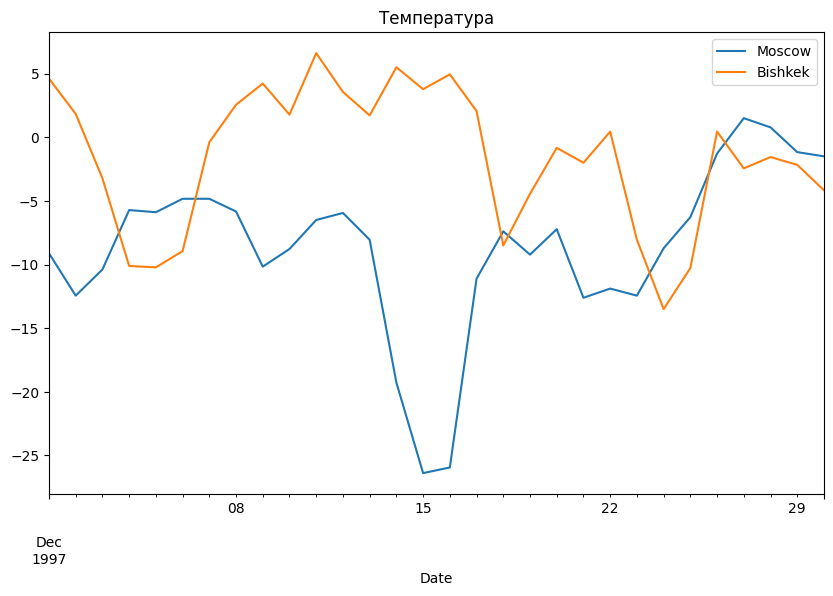

In [ ]:
moscow = df[df.City == 'Moscow'].set_index('Date')['TempC']
bishkek = df[df.City == 'Bishkek'].set_index('Date')['TempC']
df2 = pd.DataFrame()
df2['Moscow'] = moscow
df2 = df2.join(bishkek)
df2.columns = ['Moscow','Bishkek']
df2 = df2.map(lambda x:None if x<-40 else x)
df2 = df2.dropna()
df2.iloc[:30].plot()
plt.title('Температура')


In [ ]:
# Создаем простые данные для демонстрации
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Создаем фигуру и оси
fig, ax = plt.subplots(figsize=(10, 5))

# Строим график
ax.plot(x, y,
        color='blue',        # Синий цвет
        linestyle='-',       # Сплошная линия
        linewidth=2,         # Толщина 2
        marker='o',          # Круглые маркеры
        markersize=8,        # Размер маркеров
        label='Данные')      # Название для легенды

# Оформление
ax.set_title('Простой линейный график', fontsize=14, fontweight='bold')
ax.set_xlabel('Ось X', fontsize=12)
ax.set_ylabel('Ось Y', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)  # Полупрозрачная сетка

plt.tight_layout()
plt.show()

### Несколько линий на одном графике

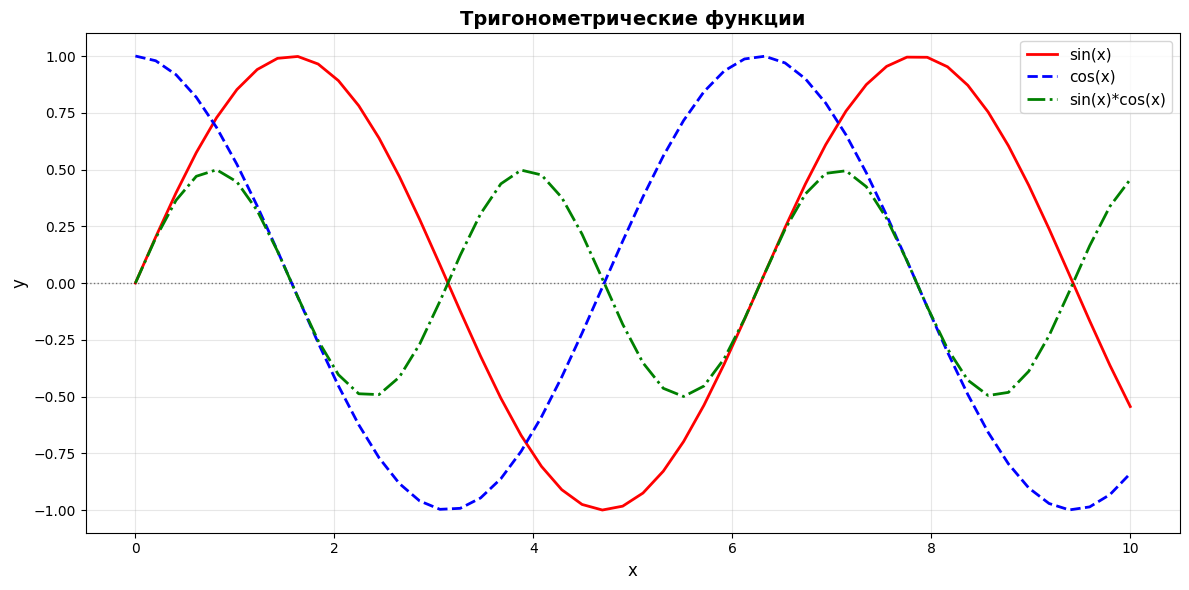

Совет: Используйте разные цвета и стили линий для различения данных!


In [ ]:
# Создаем данные для нескольких линий
x = np.linspace(0, 10, 50)  # 50 точек от 0 до 10
y1 = np.sin(x)              # Синус
y2 = np.cos(x)              # Косинус
y3 = np.sin(x) * np.cos(x)  # Произведение

# Создаем график
fig, ax = plt.subplots(figsize=(12, 6))

# Строим три линии с разными стилями
ax.plot(x, y1,
        color='red',
        linestyle='-',      # Сплошная
        linewidth=2,
        label='sin(x)')

ax.plot(x, y2,
        color='blue',
        linestyle='--',     # Пунктир
        linewidth=2,
        label='cos(x)')

ax.plot(x, y3,
        color='green',
        linestyle='-.',     # Штрих-пунктир
        linewidth=2,
        label='sin(x)*cos(x)')

# Добавляем горизонтальную линию на y=0
ax.axhline(y=0, color='black', linestyle=':', linewidth=1, alpha=0.5)

# Оформление
ax.set_title('Тригонометрические функции', fontsize=14, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=11, loc='upper right')  # Легенда в правом верхнем углу
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Совет: Используйте разные цвета и стили линий для различения данных!")

### ПРАКТИКА

**Задание:**
1. Выбери город из датасета (например, 'Moscow', 'New York', 'London', 'Tokyo')
2. Отфильтруй данные за 2019 год и конкретный месяц (например, январь)
3. Построй линейный график температуры по дням
4. Добавь заголовок, подписи осей, сетку

**Подсказка:**
```python
# Отфильтровать данные
city_data = df[(df['City'] == 'Moscow') & (df['Year'] == 2019) & (df['Month'] == 1)]

# Построить график
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(city_data['Day'], city_data['TempC'], ...)
```

In [ ]:
# График температуры для выбранного города



### Сравнение нескольких городов

**Задание:**
1. Выбери 3-4 города
2. Построй их температуры на одном графике за один и тот же месяц
3. Используй разные цвета и маркеры
4. Добавь легенду

In [ ]:
#  ТВОЙ КОД ЗДЕСЬ - Сравнение городов



---
## 3. Столбчатая диаграмма (Bar Plot)

### Когда использовать?

**Идеально для:**
- Сравнения значений между категориями
- Показа распределения по группам
- Ранжирования данных

**Примеры:** продажи по регионам, средняя зарплата по специальностям, температура по месяцам

---

### Основные функции

```python
plt.bar(x, height)          # Вертикальные столбцы (pyplot)
ax.bar(x, height)           # Вертикальные столбцы (OO)
ax.barh(y, width)           # Горизонтальные столбцы (OO)
```

### Важные параметры:

| Параметр | Описание | Примеры |
|----------|----------|----------|
| `x` / `y` | Позиции столбцов | `[1, 2, 3]`, `['A', 'B', 'C']` |
| `height` / `width` | Высота/ширина столбцов | `[10, 20, 15]` |
| `color` | Цвет столбцов | `'blue'`, `['red', 'green', 'blue']` |
| `edgecolor` | Цвет границы | `'black'`, `'white'` |
| `linewidth` | Толщина границы | `1`, `2` |
| `width` (для bar) | Ширина столбцов | `0.5`, `0.8` (по умолчанию 0.8) |
| `alpha` | Прозрачность | `0.5`, `0.8`, `1.0` |
| `label` | Название для легенды | `'Продажи'` |

### Полезные функции:

```python
ax.bar_label(bars)          # Добавить значения над столбцами
ax.set_xticks(positions)    # Установить позиции меток на оси X
ax.set_xticklabels(labels)  # Установить названия меток
```

### Простая столбчатая диаграмма

In [ ]:
moscow.iloc[2:7]

,TempC
Date,
1995-01-03,-2.888889
1995-01-04,-8.944444
1995-01-05,-4.555556
1995-01-06,-9.277778
1995-01-07,-9.388889


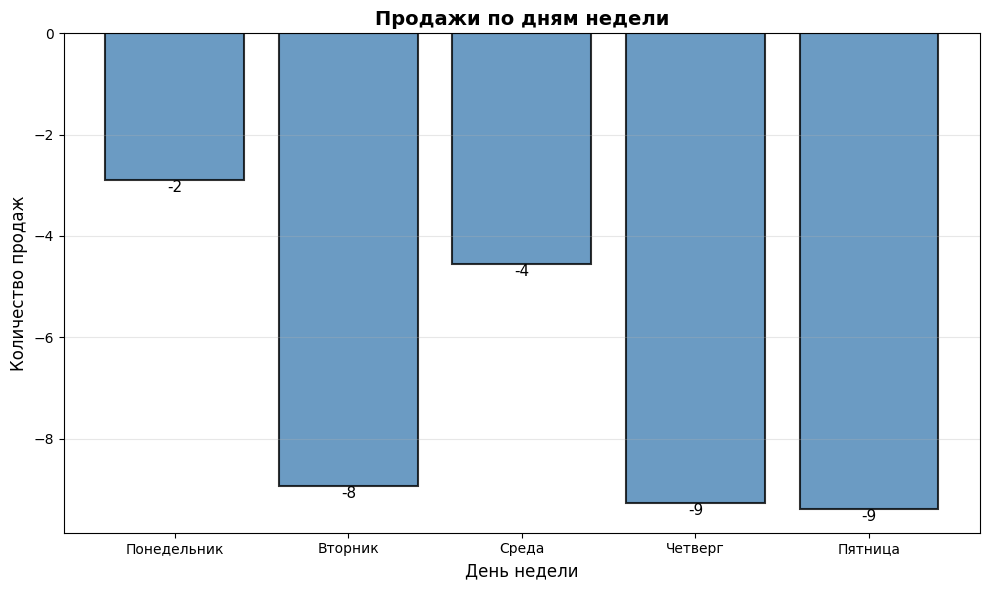

In [ ]:
# Простой пример данных
categories = ['Понедельник', 'Вторник', 'Среда', 'Четверг', 'Пятница']
values = moscow.iloc[2:7]

# Создаем график
fig, ax = plt.subplots(figsize=(10, 6))

# Строим столбцы
bars = ax.bar(categories,           # Категории по оси X
              values,               # Высота столбцов
              color='steelblue',    # Цвет
              edgecolor='black',    # Цвет границы
              linewidth=1.5,        # Толщина границы
              alpha=0.8)            # Прозрачность

# Добавляем значения над столбцами (автоматически)
ax.bar_label(bars, fmt='%d', fontsize=11)

# Оформление
ax.set_title('Продажи по дням недели', fontsize=14, fontweight='bold')
ax.set_xlabel('День недели', fontsize=12)
ax.set_ylabel('Количество продаж', fontsize=12)
ax.grid(axis='y', alpha=0.3)  # Сетка только по оси Y

plt.tight_layout()
plt.show()

### Столбцы с разными цветами

In [ ]:
# Данные
products = ['Товар A', 'Товар B', 'Товар C', 'Товар D', 'Товар E']
sales = [150, 200, 120, 180, 90]

# Создаем цвета в зависимости от значений
# Красный - если меньше 150, зеленый - если больше
colors = ['red' if s < 150 else 'green' for s in sales]

fig, ax = plt.subplots(figsize=(10, 6))

# Строим столбцы
bars = ax.bar(products, sales, color=colors, edgecolor='black', linewidth=1.5)

# Добавляем значения вручную (с большим контролем)
for i, (product, value) in enumerate(zip(products, sales)):
    ax.text(i,                    # x-координата (номер столбца)
            value + 5,            # y-координата (чуть выше столбца)
            f'{value}',           # Текст
            ha='center',          # Горизонтальное выравнивание
            fontsize=11,
            fontweight='bold')

# Добавляем горизонтальную линию на уровне 150 (порог)
ax.axhline(y=150, color='blue', linestyle='--', linewidth=2,
           label='Целевой уровень', alpha=0.7)

# Оформление
ax.set_title('Продажи товаров (красный = ниже цели)', fontsize=14, fontweight='bold')
ax.set_xlabel('Товар', fontsize=12)
ax.set_ylabel('Объем продаж', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Горизонтальная столбчатая диаграмма

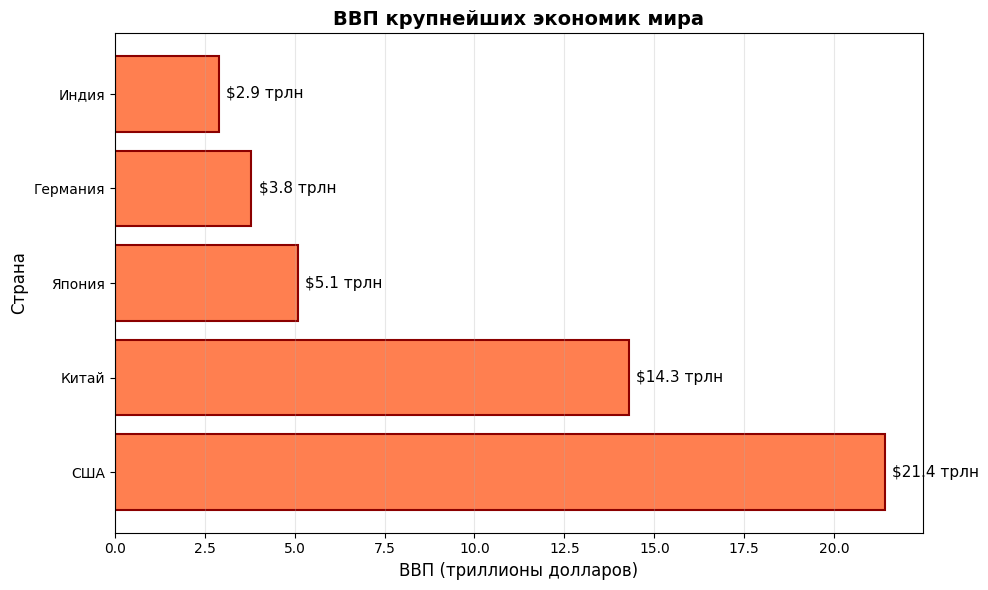

Совет: Горизонтальные столбцы удобны, когда много категорий или длинные названия!


In [ ]:
# Данные отсортированы по убыванию для наглядности
countries = ['США', 'Китай', 'Япония', 'Германия', 'Индия']
gdp = [21.4, 14.3, 5.1, 3.8, 2.9]  # ВВП в триллионах долларов

fig, ax = plt.subplots(figsize=(10, 6))

# Горизонтальные столбцы (barh)
bars = ax.barh(countries,      # Категории по оси Y
               gdp,            # Длина столбцов по оси X
               color='coral',
               edgecolor='darkred',
               linewidth=1.5)

# Добавляем значения справа от столбцов
for i, (country, value) in enumerate(zip(countries, gdp)):
    ax.text(value + 0.2,      # x-координата (справа от столбца)
            i,                # y-координата (номер строки)
            f'${value} трлн',
            va='center',      # Вертикальное выравнивание
            fontsize=11)

# Оформление
ax.set_title('ВВП крупнейших экономик мира', fontsize=14, fontweight='bold')
ax.set_xlabel('ВВП (триллионы долларов)', fontsize=12)
ax.set_ylabel('Страна', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Совет: Горизонтальные столбцы удобны, когда много категорий или длинные названия!")

### Средняя температура по месяцам

**Задание:**
1. Выбери город и год
2. Посчитай среднюю температуру для каждого месяца
3. Построй столбчатую диаграмму
4. Раскрась столбцы в зависимости от температуры (холодные - синий, теплые - красный)

**Подсказка:**
```python
# Группировка и подсчет средней
monthly_avg = city_data.groupby('Month')['TempC'].mean()

# Цвета в зависимости от температуры
colors = ['blue' if temp < 0 else 'orange' if temp < 15 else 'red'
          for temp in monthly_avg.values]
```

<BarContainer object of 12 artists>

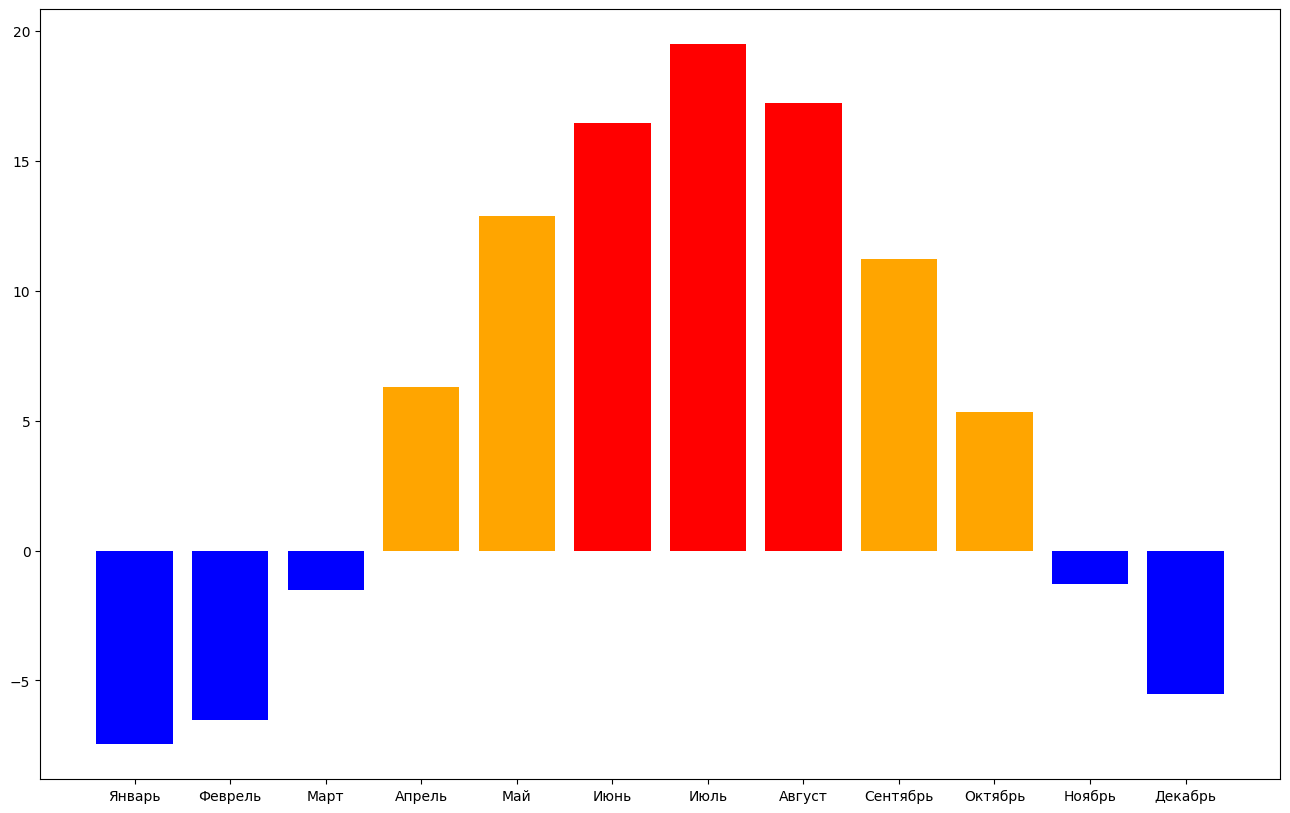

In [ ]:
monthly_avg = df[df['City']=='Moscow'].groupby('Month')['TempC'].mean()
monthly_avg
# Цвета в зависимости от температуры
colors = ['blue' if temp < 0 else 'orange' if temp < 15 else 'red' for temp in monthly_avg.values]
plt.figure(figsize=[16,10])
plt.bar(['Январь', 'Феврель', 'Март', 'Апрель', 'Май', 'Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'],monthly_avg, color = colors)

### Сравнение городов (горизонтальные столбцы)

**Задание:**
1. Выбери несколько городов (5-7)
2. Посчитай среднюю температуру за весь год
3. Построй горизонтальную столбчатую диаграмму
4. Отсортируй от холодного к теплому

In [ ]:
# Сравнение городов



---
## 4. Гистограмма (Histogram)

### Когда использовать?

**Идеально для:**
- Показа распределения непрерывных данных
- Понимания формы данных (нормальное распределение, скошенное и т.д.)
- Поиска аномалий и выбросов

**Примеры:** распределение возраста, доходов, температур, оценок

---

### Важно: Разница между Bar Plot и Histogram

| Характеристика | Bar Plot | Histogram |
|---------------|----------|----------|
| **Тип данных** | Категориальные | Непрерывные числовые |
| **Ось X** | Категории (названия) | Интервалы значений |
| **Что показывает** | Сравнение между группами | Распределение данных |
| **Пример** | Продажи по месяцам | Сколько людей ростом 160-170 см |

---

### Основная функция

```python
ax.hist(data, bins=10)  # data - данные, bins - количество столбцов
```

### Важные параметры:

| Параметр | Описание | Примеры |
|----------|----------|----------|
| `x` | Данные для гистограммы | `[1, 2, 2, 3, 3, 3, 4, ...]` |
| `bins` | Количество столбцов | `10`, `20`, `[0, 10, 20, 30]` |
| `color` | Цвет столбцов | `'skyblue'` |
| `edgecolor` | Цвет границ | `'black'` |
| `alpha` | Прозрачность | `0.7` |
| `density` | Нормировать (площадь = 1) | `True` / `False` |
| `cumulative` | Кумулятивная гистограмма | `True` / `False` |

**Выбор bins (количества интервалов):**
- Слишком мало → потеря деталей
- Слишком много → слишком шумно
- Обычно: 10-30 интервалов
- Можно использовать `bins='auto'` для автоматического выбора

### Простая гистограмма

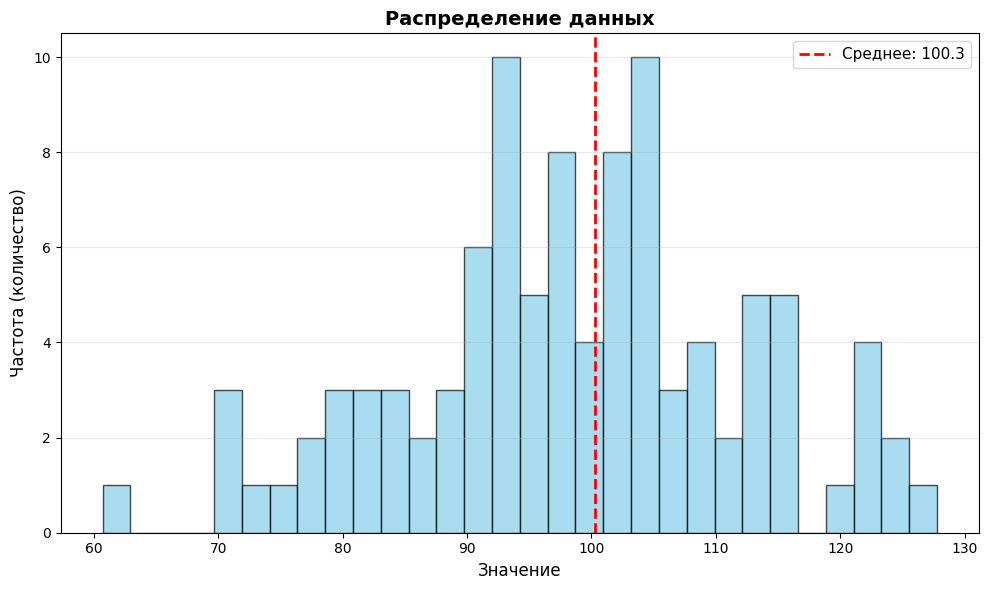

Среднее: 100.29
Медиана: 100.38
Стандартное отклонение: 14.68


In [ ]:
# Генерируем случайные данные (нормальное распределение)
np.random.seed(42)
data = np.random.normal(100, 15, 1000)  # среднее=100, std=15, 1000 значений

fig, ax = plt.subplots(figsize=(10, 6))

# Строим гистограмму
n, bins, patches = ax.hist(data[:100],              # Данные
                           bins=30,           # 30 интервалов
                           color='skyblue',   # Цвет
                           edgecolor='black', # Цвет границ
                           alpha=0.7)         # Прозрачность

# Добавляем вертикальную линию среднего значения
mean_val = np.mean(data)
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
           label=f'Среднее: {mean_val:.1f}')

# Оформление
ax.set_title('Распределение данных', fontsize=14, fontweight='bold')
ax.set_xlabel('Значение', fontsize=12)
ax.set_ylabel('Частота (количество)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Среднее: {np.mean(data):.2f}")
print(f"Медиана: {np.median(data):.2f}")
print(f"Стандартное отклонение: {np.std(data):.2f}")

### Сравнение распределений

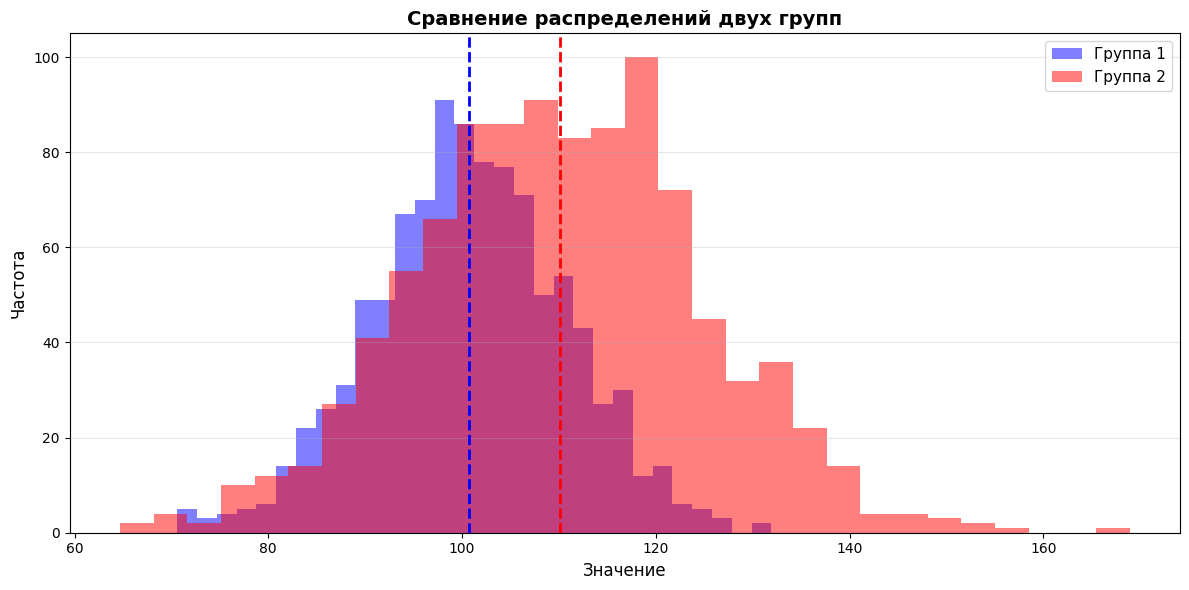

Совет: Используйте alpha (прозрачность) для видимости перекрывающихся данных!


In [ ]:
# Генерируем два набора данных
data1 = np.random.normal(100, 10, 1000)  # Первая группа
data2 = np.random.normal(110, 15, 1000)  # Вторая группа (выше среднее)

fig, ax = plt.subplots(figsize=(12, 6))

# Строим две гистограммы на одном графике
ax.hist(data1,
        bins=30,
        color='blue',
        alpha=0.5,           # Полупрозрачные для видимости перекрытия
        label='Группа 1')

ax.hist(data2,
        bins=30,
        color='red',
        alpha=0.5,
        label='Группа 2')

# Добавляем вертикальные линии средних
ax.axvline(np.mean(data1), color='blue', linestyle='--', linewidth=2)
ax.axvline(np.mean(data2), color='red', linestyle='--', linewidth=2)

# Оформление
ax.set_title('Сравнение распределений двух групп', fontsize=14, fontweight='bold')
ax.set_xlabel('Значение', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Совет: Используйте alpha (прозрачность) для видимости перекрывающихся данных!")

###  Распределение температур

**Задание:**
1. Возьми данные по температуре для выбранного города за год
2. Построй гистограмму распределения температур
3. Добавь вертикальные линии для среднего, минимума и максимума
4. Поэкспериментируй с количеством bins

**Подсказка:**
```python
# Получить все температуры
temperatures = city_data['TempC'].dropna()

# Построить гистограмму
ax.hist(temperatures, bins=30, ...)

# Добавить линии
ax.axvline(temperatures.mean(), color='red', label='Среднее')
```

/tmp/ipython-input-2123496773.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  moscow = moscow.fillna(method='ffill')


<Axes: >

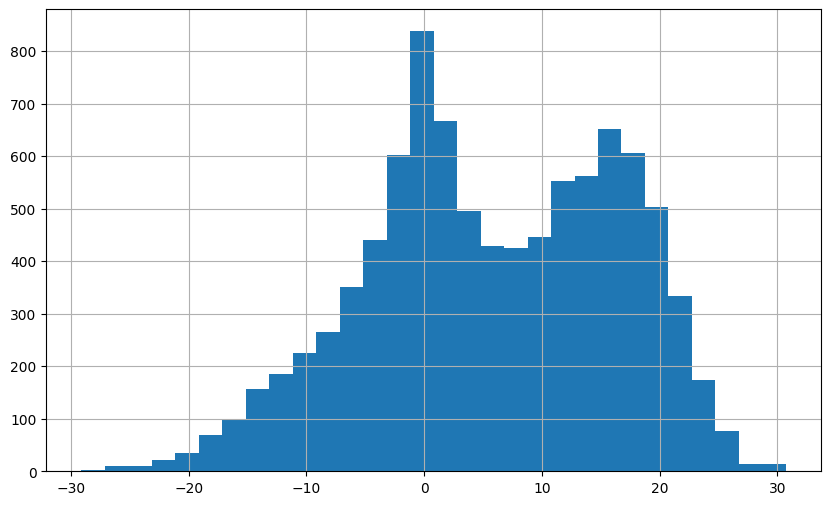

In [ ]:
# Распределение температур
moscow = df[df.City == 'Moscow']
moscow = moscow.set_index('Date')
moscow = moscow['TempC']
moscow = moscow.apply(lambda x:None if x<-40 else x)
moscow = moscow.fillna(method='ffill')
moscow.hist(bins=30)

---
## 5. Диаграмма рассеяния (Scatter Plot)

### Когда использовать?

**Идеально для:**
- Показа взаимосвязи между двумя переменными
- Поиска корреляций
- Выявления кластеров и выбросов

**Примеры:** рост vs вес, зарплата vs опыт, температура vs влажность

---

### Основная функция

```python
ax.scatter(x, y)  # x и y - две переменные
```

### Важные параметры:

| Параметр | Описание | Примеры |
|----------|----------|----------|
| `x, y` | Координаты точек | `x=[1,2,3], y=[2,4,6]` |
| `s` | Размер точек | `20`, `50`, `[10, 20, 30, ...]` |
| `c` | Цвет точек | `'red'`, `[1, 2, 3, ...]` (числа → цветовая карта) |
| `marker` | Форма маркера | `'o'`, `'s'`, `'^'`, `'*'` |
| `alpha` | Прозрачность | `0.5`, `0.8` |
| `cmap` | Цветовая карта | `'viridis'`, `'coolwarm'`, `'plasma'` |
| `edgecolors` | Цвет границы точек | `'black'` |
| `linewidths` | Толщина границы | `1`, `2` |

**Дополнительно:**
```python
plt.colorbar()  # Добавить цветовую шкалу (если используется cmap)
```

### Простая диаграмма рассеяния

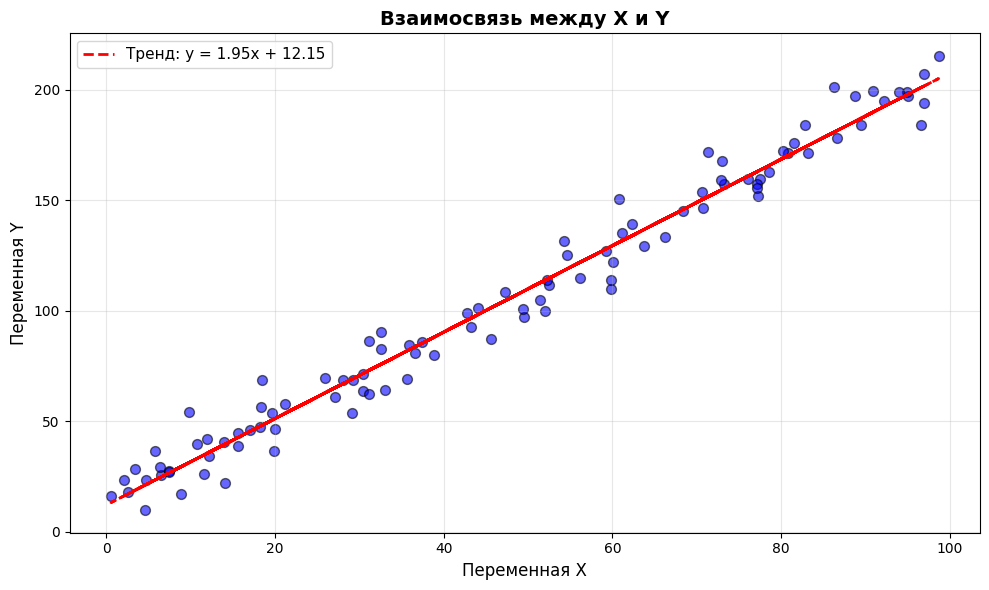

Корреляция: 0.988


In [ ]:
# Генерируем данные с корреляцией
np.random.seed(42)
x = np.random.rand(100) * 100
y = 2 * x + 10 + np.random.randn(100) * 10  # y зависит от x + шум

fig, ax = plt.subplots(figsize=(10, 6))

# Строим точки
ax.scatter(x, y,
           s=50,                    # Размер точек
           color='blue',            # Цвет
           alpha=0.6,               # Прозрачность
           edgecolors='black',      # Цвет границы
           linewidths=1)            # Толщина границы

# Добавляем линию тренда
z = np.polyfit(x, y, 1)  # Полином 1-й степени (линейная регрессия)
p = np.poly1d(z)
ax.plot(x, p(x), "r--", linewidth=2, label=f'Тренд: y = {z[0]:.2f}x + {z[1]:.2f}')

# Оформление
ax.set_title('Взаимосвязь между X и Y', fontsize=14, fontweight='bold')
ax.set_xlabel('Переменная X', fontsize=12)
ax.set_ylabel('Переменная Y', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Считаем корреляцию
correlation = np.corrcoef(x, y)[0, 1]
print(f"Корреляция: {correlation:.3f}")

###  Scatter с цветовой картой

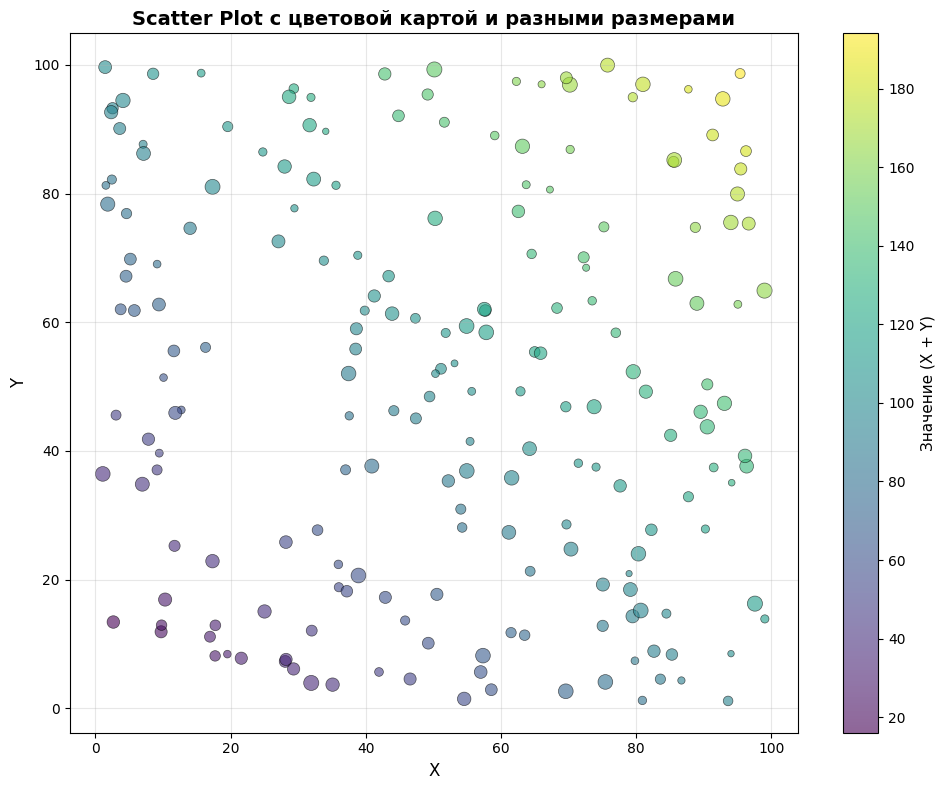

Совет: Используйте размер и цвет точек для отображения дополнительных измерений!


In [ ]:
# Генерируем данные
n = 200
x = np.random.rand(n) * 100
y = np.random.rand(n) * 100
colors = x + y  # Цвет зависит от суммы x и y
sizes = np.random.rand(n) * 100 + 20  # Разные размеры точек

fig, ax = plt.subplots(figsize=(10, 8))

# Строим scatter с цветовой картой
scatter = ax.scatter(x, y,
                     s=sizes,               # Размеры варьируются
                     c=colors,              # Цвета зависят от значений
                     cmap='viridis',        # Цветовая карта
                     alpha=0.6,
                     edgecolors='black',
                     linewidths=0.5)

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Значение (X + Y)', fontsize=11)

# Оформление
ax.set_title('Scatter Plot с цветовой картой и разными размерами',
             fontsize=14, fontweight='bold')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Совет: Используйте размер и цвет точек для отображения дополнительных измерений!")

### ПРАКТИКА

**Задание:**
1. Выбери два города
2. Найди даты, когда есть данные по обоим городам
3. Построй scatter plot: температура города 1 vs температура города 2
4. Добавь линию тренда
5. Посчитай корреляцию

**Подсказка:**
```python
# Получить данные двух городов
city1_data = df[df['City'] == 'Moscow'][['Date', 'TempC']]
city2_data = df[df['City'] == 'London'][['Date', 'TempC']]

# Объединить по дате
merged = pd.merge(city1_data, city2_data, on='Date', suffixes=('_city1', '_city2'))
```

In [ ]:
# Scatter plot двух городов



---
## 6. Круговая диаграмма (Pie Chart)

### Когда использовать?

**Идеально для:**
- Показа долей/процентов от целого
- Сравнения частей одного целого

**Ограничения:**
- Не более 5-7 категорий (иначе сложно читать)
- Не подходит для точного сравнения значений

**Примеры:** доля рынка, структура расходов, распределение по категориям

---

### Основная функция

```python
ax.pie(sizes, labels=labels)
```

### Важные параметры:

| Параметр | Описание | Примеры |
|----------|----------|----------|
| `x` | Размеры секторов | `[30, 20, 50]` |
| `labels` | Названия секторов | `['A', 'B', 'C']` |
| `colors` | Цвета секторов | `['red', 'blue', 'green']` |
| `autopct` | Формат процентов | `'%1.1f%%'` (1 знак после запятой) |
| `startangle` | Угол начала | `90` (начать сверху) |
| `explode` | Отделение секторов | `[0, 0.1, 0]` (второй отодвинут) |
| `shadow` | Тень | `True` / `False` |
| `wedgeprops` | Свойства секторов | `{'edgecolor': 'black'}` |

### Простая круговая диаграмма

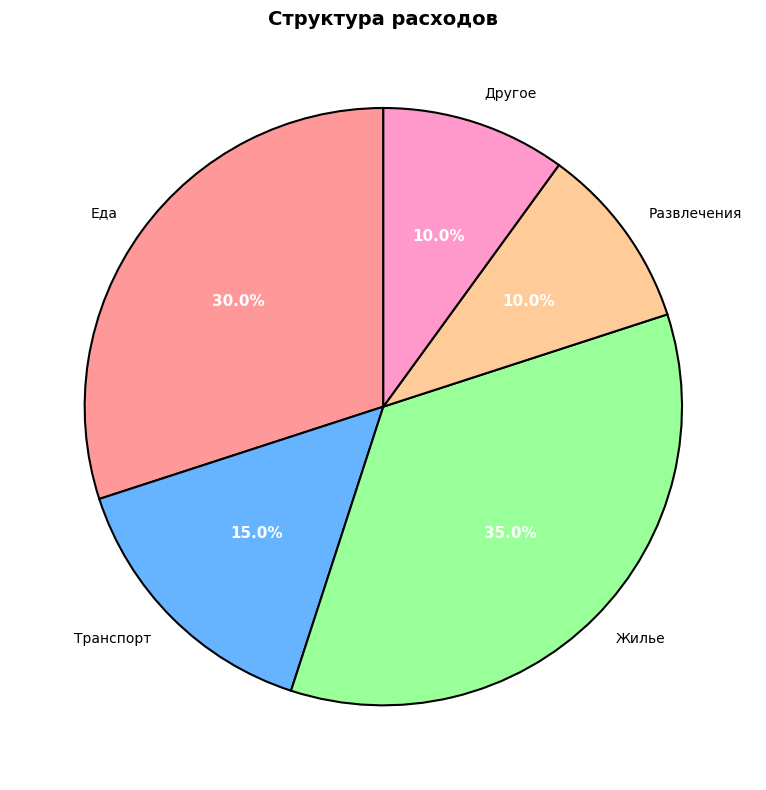

In [ ]:
# Данные
categories = ['Еда', 'Транспорт', 'Жилье', 'Развлечения', 'Другое']
values = [30, 15, 35, 10, 10]
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']

fig, ax = plt.subplots(figsize=(10, 8))

# Строим круговую диаграмму
wedges, texts, autotexts = ax.pie(values,
                                   labels=categories,
                                   colors=colors,
                                   autopct='%1.1f%%',  # Формат процентов
                                   startangle=90,       # Начать сверху
                                   shadow=False,
                                   wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

# Делаем текст процентов жирным и белым
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Оформление
ax.set_title('Структура расходов', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Круговая диаграмма с выделением

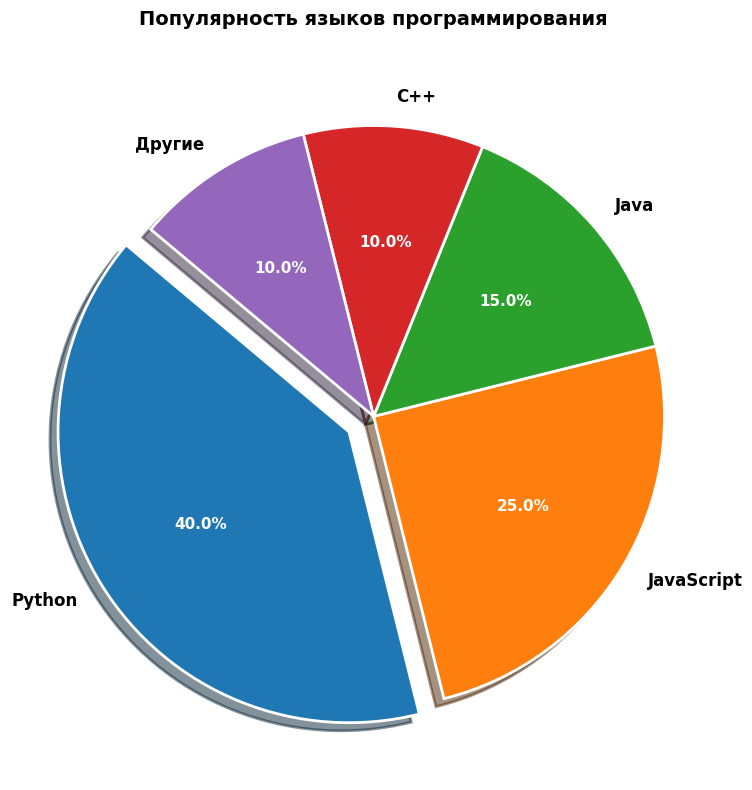

Совет: Используйте explode для акцента на важном секторе!


In [ ]:
# Данные
labels = ['Python', 'JavaScript', 'Java', 'C++', 'Другие']
sizes = [40, 25, 15, 10, 10]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
explode = [0.1, 0, 0, 0, 0]  # Выделяем Python

fig, ax = plt.subplots(figsize=(10, 8))

# Строим диаграмму
wedges, texts, autotexts = ax.pie(sizes,
                                   labels=labels,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=140,
                                   explode=explode,     # Отделяем первый сектор
                                   shadow=True,         # Добавляем тень
                                   wedgeprops={'edgecolor': 'white', 'linewidth': 2})

# Настраиваем текст
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Оформление
ax.set_title('Популярность языков программирования',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("Совет: Используйте explode для акцента на важном секторе!")

### Распределение записей по городам

**Задание:**
1. Выбери топ-5 городов по количеству записей в датасете
2. Построй круговую диаграмму, показывающую их доли
3. Используй красивые цвета
4. Добавь проценты

**Подсказка:**
```python
# Подсчитать количество записей по городам
city_counts = df['City'].value_counts().head(5)
```

In [ ]:
# Круговая диаграмма городов



---
## 7. Subplots - Несколько графиков

### Зачем нужны subplots?

Часто нужно показать несколько связанных графиков рядом для сравнения.

---

### Создание subplots

```python
# Вариант 1: Простой (одинаковые размеры)
fig, axes = plt.subplots(nrows, ncols, figsize=(width, height))

# Вариант 2: Гибкий (разные размеры)
fig = plt.figure(figsize=(width, height))
ax1 = fig.add_subplot(221)  # 2 строки, 2 колонки, позиция 1
ax2 = fig.add_subplot(222)  # позиция 2
```

### Доступ к отдельным графикам:

```python
fig, axes = plt.subplots(2, 2)  # 2x2 сетка

# Доступ:
axes[0, 0]  # Левый верхний
axes[0, 1]  # Правый верхний
axes[1, 0]  # Левый нижний
axes[1, 1]  # Правый нижний

# Или если одна строка/колонка:
fig, axes = plt.subplots(1, 3)  # 1x3
axes[0]  # Первый
axes[1]  # Второй
axes[2]  # Третий
```

### Общие настройки:

```python
fig.suptitle('Общий заголовок')  # Заголовок для всей фигуры
plt.tight_layout()               # Автоматическая подгонка
```

### Простые subplots (1 строка)

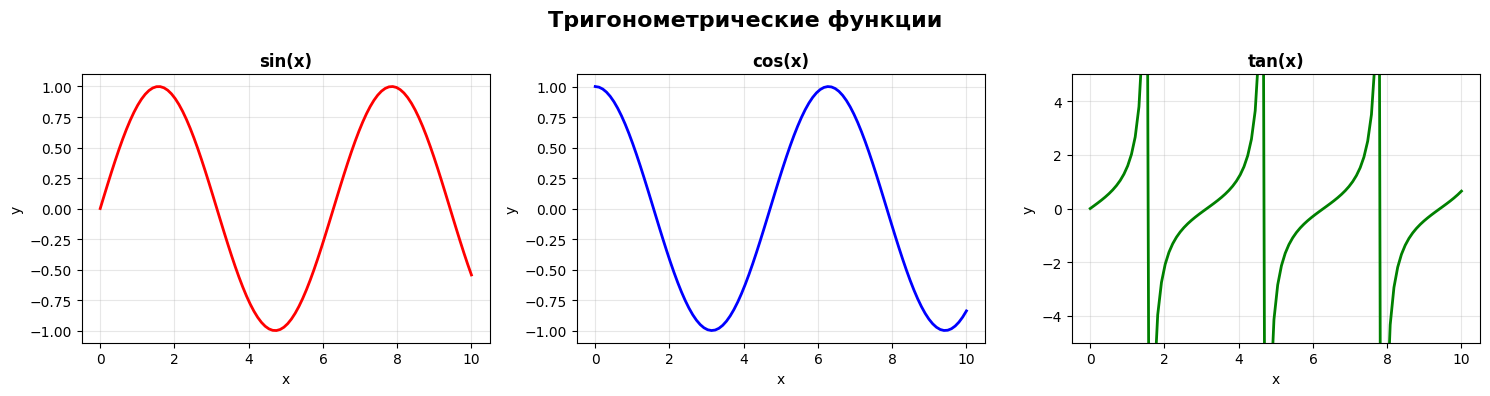

In [ ]:
# Создаем данные
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.tan(x)

# Создаем фигуру с 3 графиками в одной строке
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Первый график
axes[0].plot(x, y1, 'r-', linewidth=2)
axes[0].set_title('sin(x)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].grid(True, alpha=0.3)

# Второй график
axes[1].plot(x, y2, 'b-', linewidth=2)
axes[1].set_title('cos(x)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, alpha=0.3)

# Третий график
axes[2].plot(x, y3, 'g-', linewidth=2)
axes[2].set_title('tan(x)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_ylim([-5, 5])  # Ограничиваем y для tan
axes[2].grid(True, alpha=0.3)

# Общий заголовок
fig.suptitle('Тригонометрические функции', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Subplots сетка 2x2

In [ ]:
# Генерируем разные типы данных
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.randn(50) * 2

# Создаем сетку 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Line plot (верхний левый)
axes[0, 0].plot(x, y, 'o-', color='blue', markersize=5)
axes[0, 0].set_title('Line Plot', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
axes[0, 0].grid(True, alpha=0.3)

# График 2: Scatter plot (верхний правый)
axes[0, 1].scatter(x, y, c=y, cmap='viridis', s=50, alpha=0.6)
axes[0, 1].set_title('Scatter Plot', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')
axes[0, 1].grid(True, alpha=0.3)

# График 3: Histogram (нижний левый)
axes[1, 0].hist(y, bins=15, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Histogram', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# График 4: Bar plot (нижний правый)
categories = ['A', 'B', 'C', 'D', 'E']
values = [23, 45, 56, 78, 32]
axes[1, 1].bar(categories, values, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Bar Plot', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(axis='y', alpha=0.3)

# Общий заголовок
fig.suptitle('Четыре типа графиков', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

print("Совет: Subplots отлично подходят для сравнения разных аспектов данных!")

### Dashboard из 4 графиков

**Задание:**
Создай информационную панель (dashboard) из 4 графиков:
1. **Верхний левый**: Линейный график температуры города за год
2. **Верхний правый**: Столбчатая диаграмма средней температуры по месяцам
3. **Нижний левый**: Гистограмма распределения температур
4. **Нижний правый**: Scatter plot двух городов

Используй один город и один год для консистентности.

In [ ]:
# Dashboard из 4 графиков



---
## 8. Продвинутые настройки

### Цветовые карты (Colormaps)

Matplotlib имеет множество встроенных цветовых карт:

**Последовательные** (для непрерывных данных):
- `'viridis'` (по умолчанию) - сине-зеленый
- `'plasma'` - фиолетово-желтый
- `'inferno'` - черно-желтый
- `'cividis'` - сине-желтый (для дальтоников)

**Дивергентные** (для данных с центром):
- `'coolwarm'` - синий-красный
- `'RdYlGn'` - красный-желтый-зеленый
- `'seismic'` - синий-белый-красный

**Качественные** (для категорий):
- `'tab10'`, `'tab20'` - наборы разных цветов

---

### Стили графиков

Matplotlib позволяет использовать готовые стили:

```python
plt.style.use('seaborn-v0_8')  # Стиль seaborn
plt.style.use('ggplot')        # Стиль ggplot (R)
plt.style.use('dark_background')  # Темный фон
```

Посмотреть все доступные стили:
```python
print(plt.style.available)
```

---

### Сохранение графиков

```python
fig.savefig('график.png',      # Имя файла
            dpi=300,            # Разрешение (точек на дюйм)
            bbox_inches='tight', # Обрезать лишние поля
            facecolor='white')   # Цвет фона

# Поддерживаемые форматы: png, pdf, svg, jpg
```

---

### Настройка размера и разрешения

```python
# Установка размера фигуры
fig, ax = plt.subplots(figsize=(12, 8))  # ширина x высота в дюймах

# Установка DPI (точек на дюйм)
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
```

### Демонстрация стилей

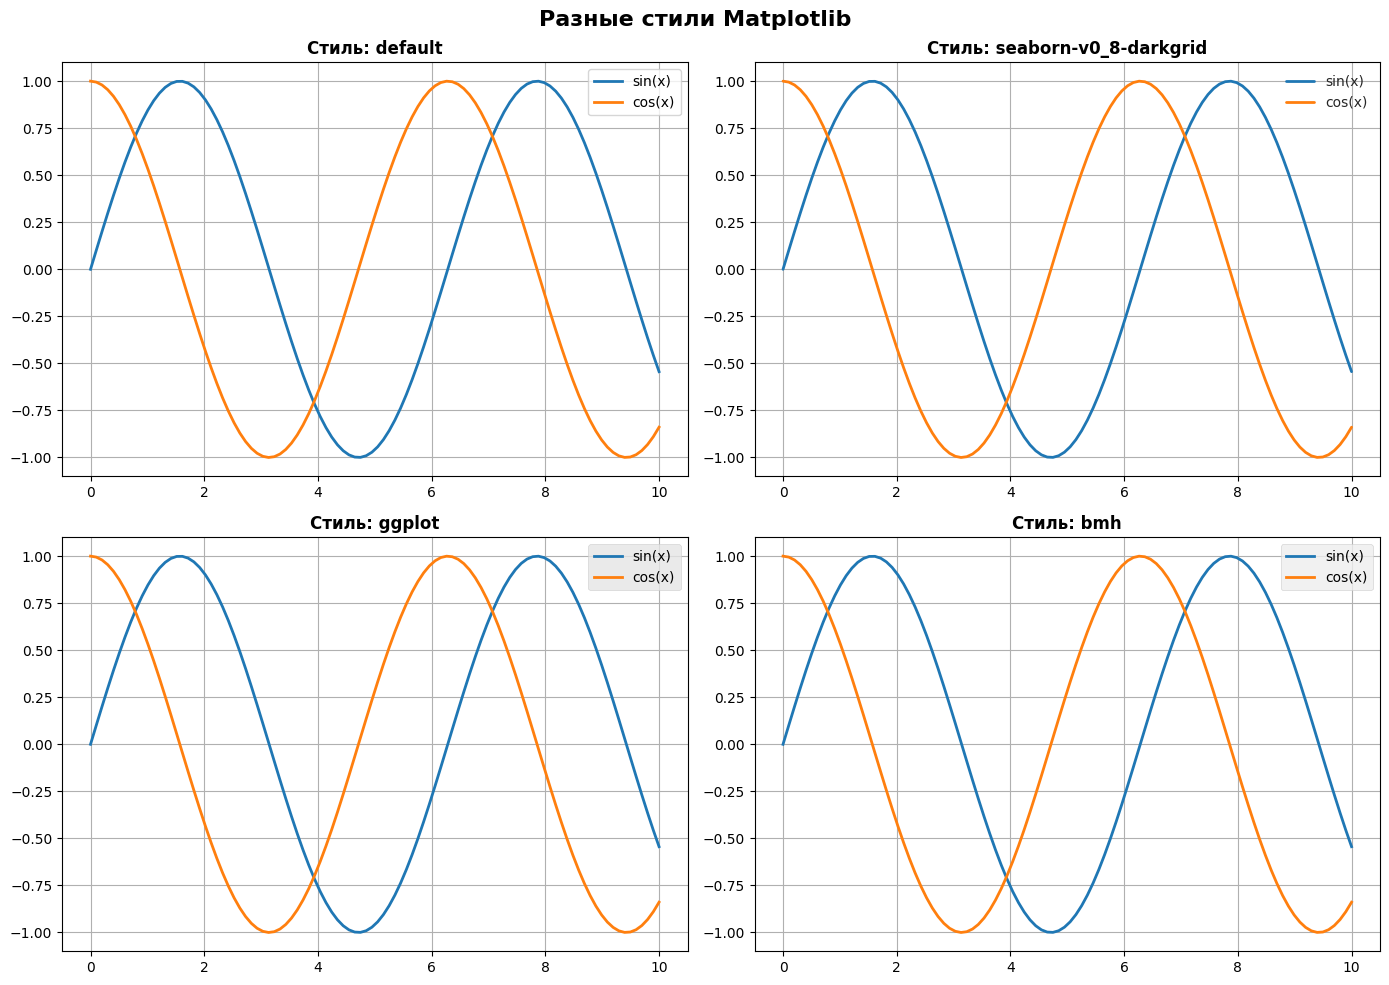

Доступные стили:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot']


In [ ]:
# Показываем несколько стилей
styles = ['default', 'seaborn-v0_8-darkgrid', 'ggplot', 'bmh']

# Данные
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, style in enumerate(styles):
    with plt.style.context(style):  # Временно применяем стиль
        axes[idx].plot(x, y1, label='sin(x)', linewidth=2)
        axes[idx].plot(x, y2, label='cos(x)', linewidth=2)
        axes[idx].set_title(f'Стиль: {style}', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True)

fig.suptitle('Разные стили Matplotlib', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Доступные стили:")
print(plt.style.available[:10])  # Первые 10

### Цветовые карты

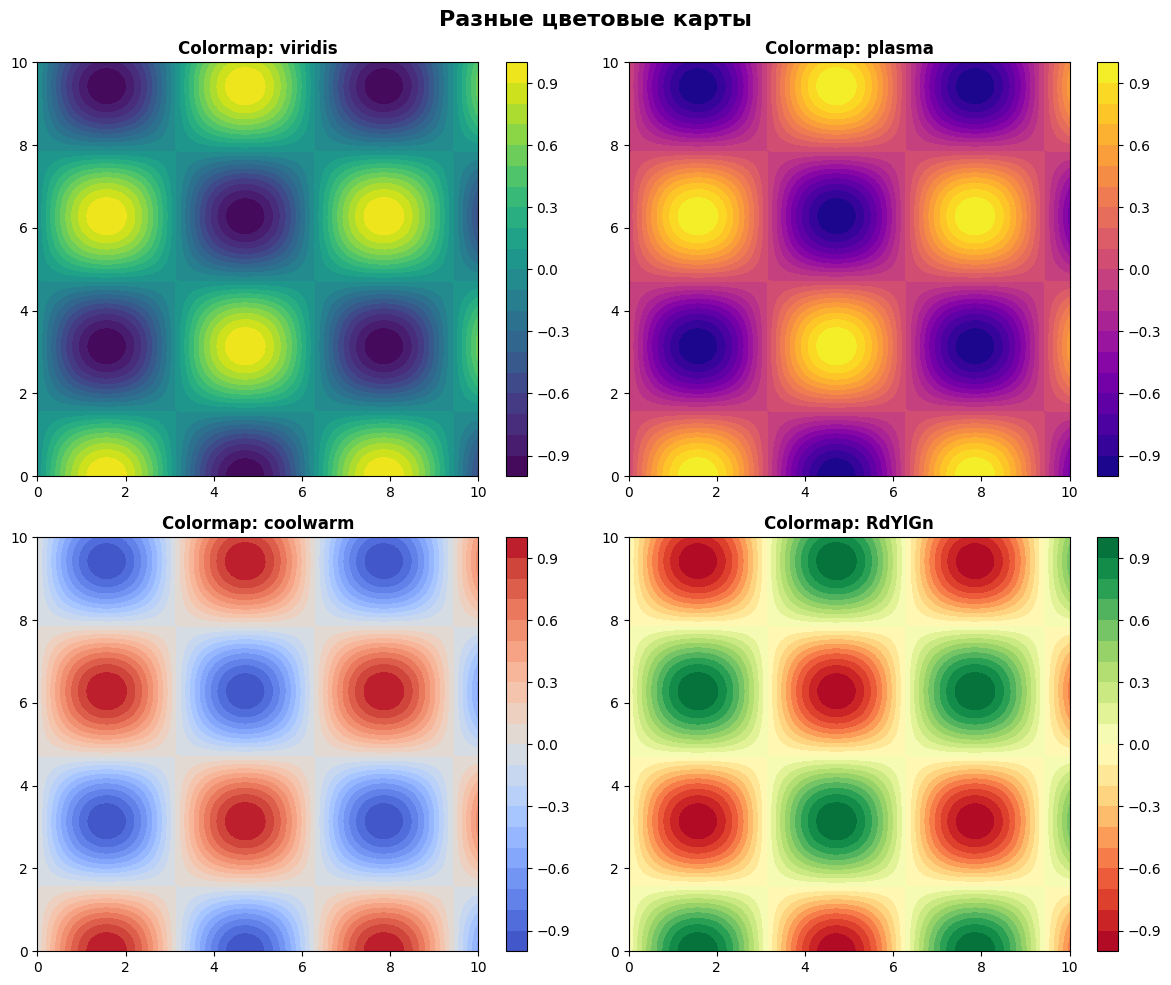

Совет: Выбирайте цветовую карту в зависимости от типа данных!
- Последовательные (viridis, plasma) - для непрерывных данных
- Дивергентные (coolwarm, RdYlGn) - для данных с центральным значением


In [ ]:
# Генерируем данные для демонстрации
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

# Разные цветовые карты
cmaps = ['viridis', 'plasma', 'coolwarm', 'RdYlGn']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, cmap in enumerate(cmaps):
    im = axes[idx].contourf(X, Y, Z, cmap=cmap, levels=20)
    axes[idx].set_title(f'Colormap: {cmap}', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=axes[idx])

fig.suptitle('Разные цветовые карты', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Совет: Выбирайте цветовую карту в зависимости от типа данных!")
print("- Последовательные (viridis, plasma) - для непрерывных данных")
print("- Дивергентные (coolwarm, RdYlGn) - для данных с центральным значением")

### Красивый финальный график

**Задание:**
1. Создай самый красивый и информативный график на основе датасета температур
2. Примени стиль (например, 'seaborn-v0_8')
3. Используй продвинутые настройки (цвета, шрифты, легенды)
4. Сохрани график в высоком качестве (dpi=300)


---
## 9. Итоговое задание

### Создай полноценный отчет по анализу температур

**Требования:**

1. **Выбери 3-5 городов для анализа**

2. **Создай комплексную визуализацию, включающую:**
   - Сравнение температур городов во времени (line plot)
   - Средние температуры по месяцам (bar plot)
   - Распределение температур (histogram)
   - Любые другие графики на ваш выбор

3. **Оформление:**
   - Используй subplots для компактного отображения
   - Примени красивый стиль
   - Добавь информативные заголовки и подписи
   - Используй разные цвета для разных городов

4. **Сохрани результат:**
   - Сохрани финальный график в файл

**Пример структуры:**
```python
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# График 1: Сравнение температур
# График 2: Средние по месяцам
# График 3: Гистограммы
# График 4: Scatter или что-то еще
```

Удачи! 🚀